# Import modules

In [1]:
import os
import requests                      # HTTP client for API calls
import pandas as pd                  # Tabular data handling
from datetime import datetime        # Datetime handling
from typing import Iterable, Optional, Dict, Union
import matplotlib.pyplot as plt
%pip install yfinance
import yfinance as yf
import sys
import os

# Get the project root (one level above "notebooks")
root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root)

from pprint import pprint as pp

Note: you may need to restart the kernel to use updated packages.


# Import functions

In [2]:
# Load the autoreload extension
%load_ext autoreload

# Reload all modules automatically before executing a cell
%autoreload 2

from src.debug_print import debug_print
from src.fetch_lse_tickers import get_ftse100
from src.exchange_rates import get_share_prices_2 as share_prices
from src.exchange_rates_v2 import get_share_prices_2_with_fundamentals
# from src.roi_hit import get_first_roi_hit
from src.roi_hit_v2 import get_first_roi_hit
from src.plot_shares_ROI import plot_candles_volatility_volume_roi as ROI
from src.extract_latest_fundamentals import extract_latest_fundamentals
from src.detect_undervalued import detect_undervalued
from src.utils.email_sender import send_email_html_multi_inline_images, build_roi_email_with_action_images


# Set up variables

In [3]:
base_currency = "GBP"
target_currencies = ["USD", "GBP", "EUR", "JPY"]
cryptos = ["BTC", "ETH"]
shares = ['FRES','ENT','GLEN','MNG','PHNX','VOD']

start_date = pd.Timestamp(2024,1,1)
purchase_date = pd.Timestamp(2026,1,2)
end_date = pd.Timestamp.today().normalize()
ROI_target = 0.135
email_sender = "carlo.danieli.trading@gmail.com"
email_sender_psw = "glid qtnr indv wond"


# Get TOP 100 shares from FTSE

In [4]:
ftse100 = get_ftse100()
ftse100["Yahoo_Ticker"] = ftse100["Ticker"] + ".L"
shares_lse = ftse100["Yahoo_Ticker"].to_list()

[DEBUG] File: c:\Users\ingca\OneDrive\Documents\python\finance\src\utils\retry_decorator.py, Function: wrapper, Line: 38
None get_ftse100 succeeded


# SHARES PRICES WITH INFO

In [5]:
df_shares_fund = get_share_prices_2_with_fundamentals(
    tickers=shares_lse,
    start=start_date,
    end=end_date,
    base_currency = base_currency,
    vol_window = 20,
    
)

actions_list   = df_shares_fund.columns.get_level_values("ACTION").unique().to_list()
currencies_list = df_shares_fund.columns.get_level_values("CURRENCY").unique()
metrics   = df_shares_fund.columns.get_level_values("METRIC").unique()

[DEBUG] File: c:\Users\ingca\OneDrive\Documents\python\finance\src\exchange_rates_v2.py, Function: get_share_prices_2_with_fundamentals, Line: 198
None df:
ACTION       WTB.L                                                           \
CURRENCY       GBp                                                            
METRIC         LOW         HIGH   CLOSE      RANGE VOLATILITY  VOLUME   EPS   
Date                                                                          
2024-01-02  3615.0  3676.000000  3615.0  61.000000        NaN  886771  1.43   
2024-01-03  3557.0  3645.000000  3573.0  88.000000        NaN  884712  1.43   
2024-01-04  3545.0  3585.000000  3581.0  40.000000        NaN  649436  1.43   
2024-01-05  3535.0  3585.000000  3559.0  50.000000        NaN  595880  1.43   
2024-01-08  3537.0  3589.000000  3589.0  52.000000        NaN  472353  1.43   
...            ...          ...     ...        ...        ...     ...   ...   
2025-12-29  2542.0  2567.000000  2542.0  25.000000   0

# EXTRACT UNDERVALUED SHARES

In [6]:
df = extract_latest_fundamentals(
    df=df_shares_fund,
    evaluation_date=purchase_date
)
undervalued_shares = detect_undervalued(df)

# UNDERVALUED SHARES' LIST

In [7]:
filt = undervalued_shares[undervalued_shares['UndervaluedScore']>0]
undervalued_shares_list = filt['UndervaluedScore'].index.to_list()

# pics_dir = os.path.join(os.getcwd(),"undervalued_shares_output")
# text_body, html_body, inline_images = build_roi_email_with_action_images(
#     roi_data=sorted_data,
#     image_dir=pics_dir,  # contains AAL.png, VOD.png, ...
# )

# send_email_html_multi_inline_images(
#     smtp_server="smtp.gmail.com",
#     smtp_port=587,
#     username=email_sender,
#     password=email_sender_psw,
#     sender=email_sender,
#     recipients=["ingcarldan@gmail.com"],
#     subject=f"FTSE100 - ROI targets reached – {datetime.today():%d-%m-%Y %H:%M}",
#     text_body=text_body,
#     html_body=html_body,
#     inline_images=inline_images,
# )

In [8]:
undervalued_shares_list_clean = [ticker.split('.')[0] for ticker in undervalued_shares_list]

print(undervalued_shares_list_clean)

# ROI(
#     df=df_shares_fund,
#     actions=undervalued_shares_list,
#     # actions=actions_list,
#     start=df_shares_fund.index.min(),
#     end=df_shares_fund.index.max(),
#     purchase_date=purchase_date,
#     roi_target=ROI_target
# )

['VOD', 'III', 'BEZ', 'EZJ', 'BLND', 'PSH', 'NWG', 'BKG', 'BARC', 'LMP', 'STAN', 'ABF', 'BRBY', 'MNG', 'CNA', 'GLEN', 'AAL', 'PHNX', 'ENT', 'IAG', 'MTLN', 'JD', 'ICG', 'HSX', 'ADM', 'PRU', 'HIK', 'IMB', 'RIO', 'GSK', 'BNZL', 'SHEL', 'SGRO', 'LLOY', 'PSN', 'WTB', 'SBRY', 'BT-A', 'LAND', 'IHG', 'MNDI', 'KGF', 'BTRW', 'SMT', 'ALW', 'FCIT', 'PCT']


# ANALYZE SHARES' PORTFOLIO to get ROI Dates

In [9]:
portfolio = {}
SHARES_FULL_LIST = [s + '.L_GBp→GBP' if not s.endswith('.L_GBp→GBP') else s for s in shares]
print(f"purchase_date:{purchase_date}")
for action in SHARES_FULL_LIST:
    try:
        action_clean = action.split(".L")[0]
        portfolio[action_clean] = get_first_roi_hit(
        df=df_shares_fund,
        action=action,
        purchase_date=purchase_date,
        roi_target=ROI_target
    )
    except Exception as e:
        print(f"{type(e).__name__}: {e}")

df_shares_fund.to_pickle("df_shares_fund.pkl")
print("portfolio")
pp(portfolio, indent=4)



purchase_date:2026-01-02 00:00:00
portfolio
{   'ENT': {   'ACTION': 'ENT.L_GBp→GBP',
               'DATE TARGET MET': None,
               'DAYS TO ACHIEVE TARGET': None,
               'EXIT ACTION PRICE': 7.78,
               'PURCHASE DATE': '02/01/2026',
               'PURCHASE PRICE': 7.71,
               'SET ROI TARGET': 0.135},
    'FRES': {   'ACTION': 'FRES.L_GBp→GBP',
                'DATE TARGET MET': None,
                'DAYS TO ACHIEVE TARGET': None,
                'EXIT ACTION PRICE': 34.96,
                'PURCHASE DATE': '02/01/2026',
                'PURCHASE PRICE': 33.52,
                'SET ROI TARGET': 0.135},
    'GLEN': {   'ACTION': 'GLEN.L_GBp→GBP',
                'DATE TARGET MET': None,
                'DAYS TO ACHIEVE TARGET': None,
                'EXIT ACTION PRICE': 4.19,
                'PURCHASE DATE': '02/01/2026',
                'PURCHASE PRICE': 4.09,
                'SET ROI TARGET': 0.135},
    'MNG': {   'ACTION': 'MNG.L_GBp→GBP',
     

#  PLOT SHARE - plot_candles_volatility_volume_roi 


In [10]:
SHARES_FULL_LIST = [s + '.L_GBP→GBP' if not s.endswith('.L_GBP→GBP') else s for s in shares]
# print(f"SHARES_FULL_LIST: {SHARES_FULL_LIST}")
# print(f"df_shares_fund:\n{df_shares_fund}")
mask = df_shares_fund.columns.get_level_values('ACTION').isin(SHARES_FULL_LIST)

df_fres = df_shares_fund.loc[:, mask]
print(f"df_fres:{df_fres}")


df_fres:Empty DataFrame
Columns: []
Index: [2024-01-02 00:00:00, 2024-01-03 00:00:00, 2024-01-04 00:00:00, 2024-01-05 00:00:00, 2024-01-08 00:00:00, 2024-01-09 00:00:00, 2024-01-10 00:00:00, 2024-01-11 00:00:00, 2024-01-12 00:00:00, 2024-01-15 00:00:00, 2024-01-16 00:00:00, 2024-01-17 00:00:00, 2024-01-18 00:00:00, 2024-01-19 00:00:00, 2024-01-22 00:00:00, 2024-01-23 00:00:00, 2024-01-24 00:00:00, 2024-01-25 00:00:00, 2024-01-26 00:00:00, 2024-01-29 00:00:00, 2024-01-30 00:00:00, 2024-01-31 00:00:00, 2024-02-01 00:00:00, 2024-02-02 00:00:00, 2024-02-05 00:00:00, 2024-02-06 00:00:00, 2024-02-07 00:00:00, 2024-02-08 00:00:00, 2024-02-09 00:00:00, 2024-02-12 00:00:00, 2024-02-13 00:00:00, 2024-02-14 00:00:00, 2024-02-15 00:00:00, 2024-02-16 00:00:00, 2024-02-19 00:00:00, 2024-02-20 00:00:00, 2024-02-21 00:00:00, 2024-02-22 00:00:00, 2024-02-23 00:00:00, 2024-02-26 00:00:00, 2024-02-27 00:00:00, 2024-02-28 00:00:00, 2024-02-29 00:00:00, 2024-03-01 00:00:00, 2024-03-04 00:00:00, 2024-03-05 

['FRES', 'ENT', 'GLEN', 'MNG', 'PHNX', 'VOD']
['ENT.L_GBp→GBP', 'FRES.L_GBp→GBP', 'GLEN.L_GBp→GBP', 'MNG.L_GBp→GBP', 'PHNX.L_GBp→GBP', 'VOD.L_GBp→GBP']


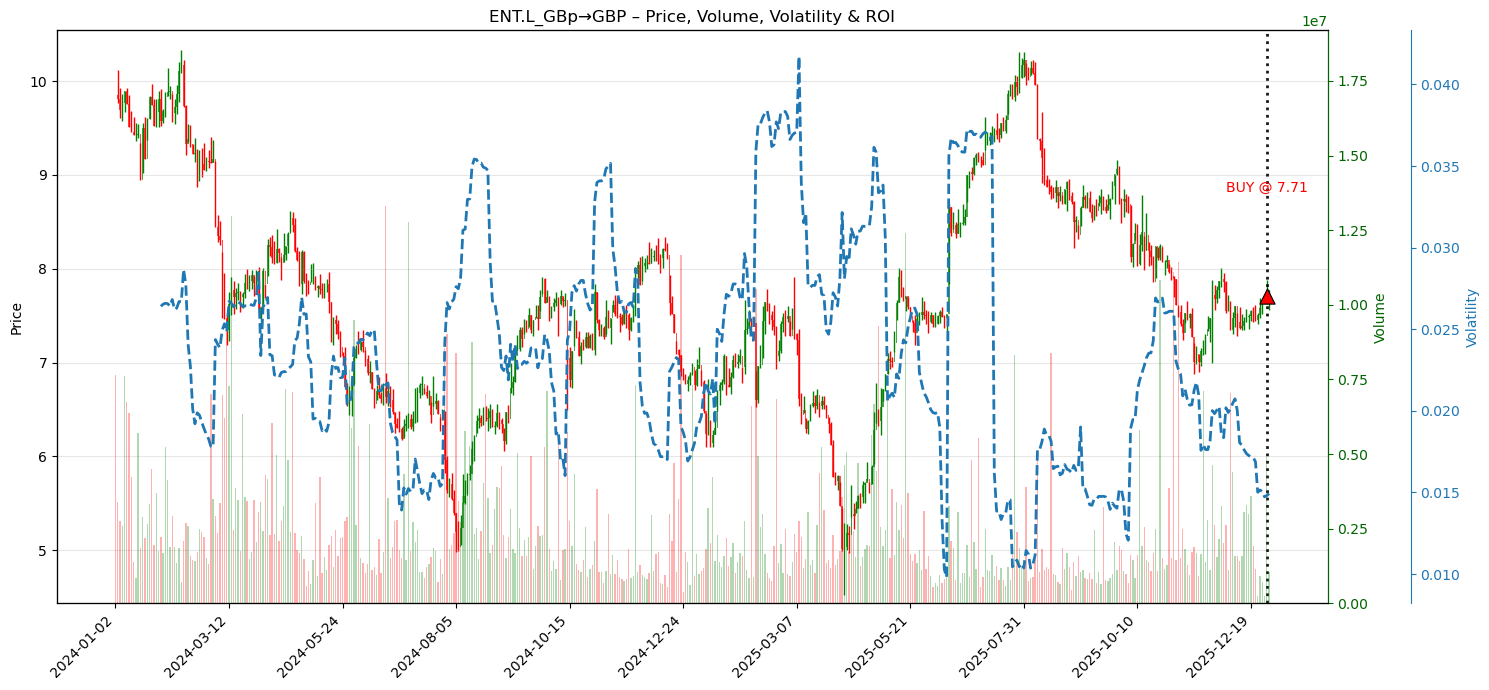

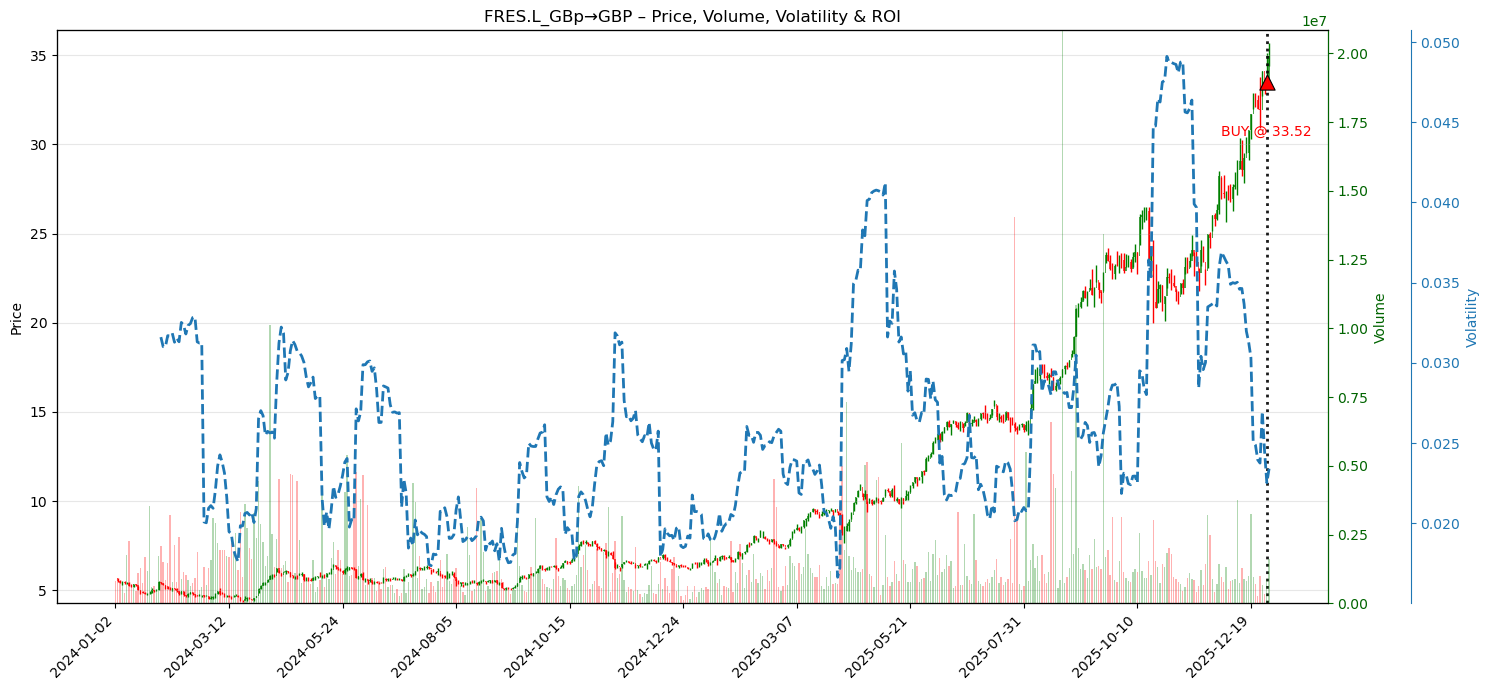

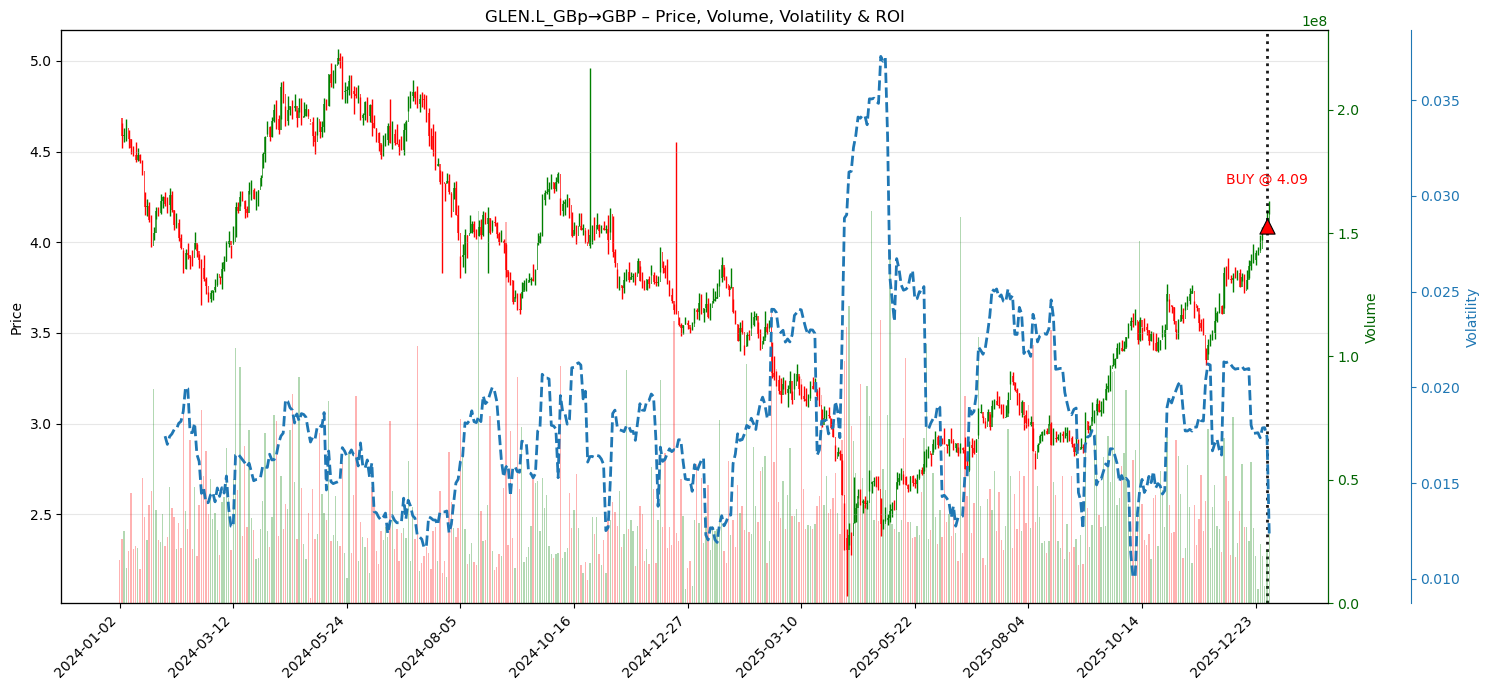

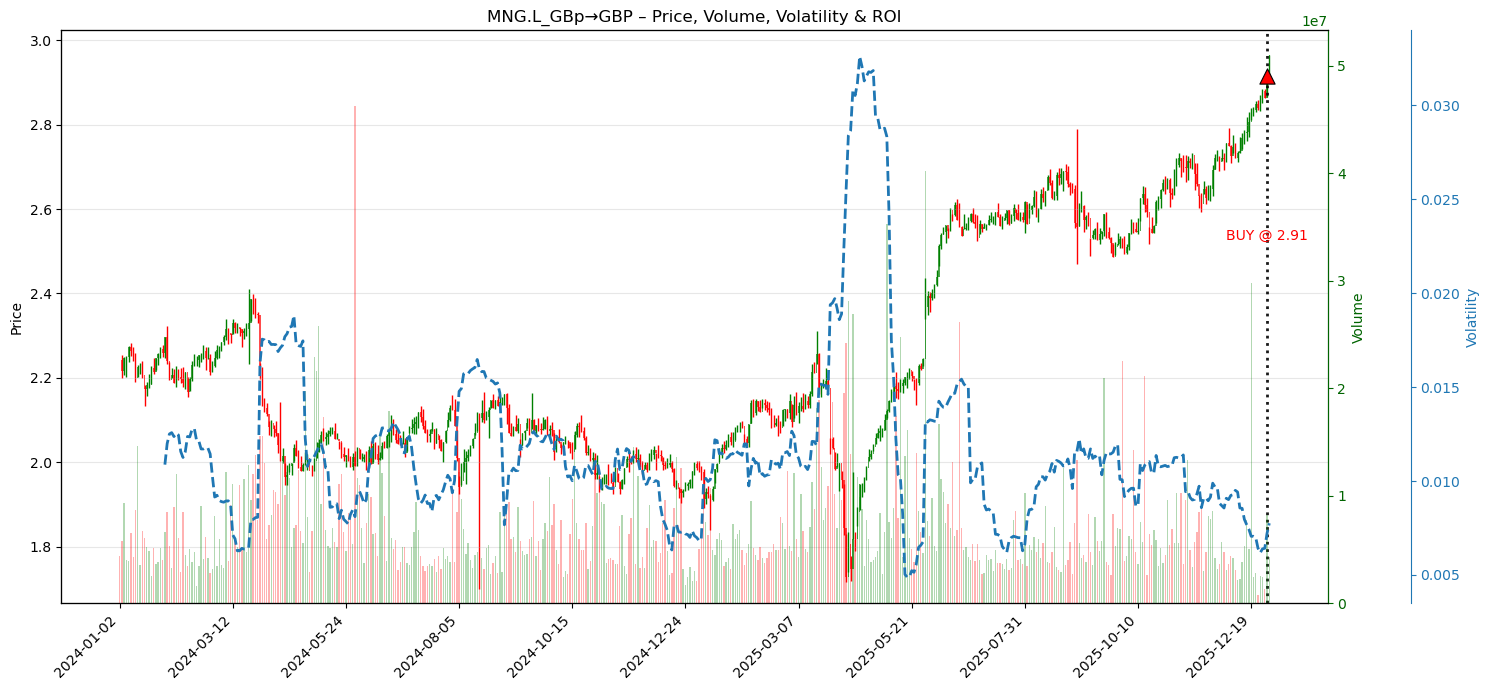

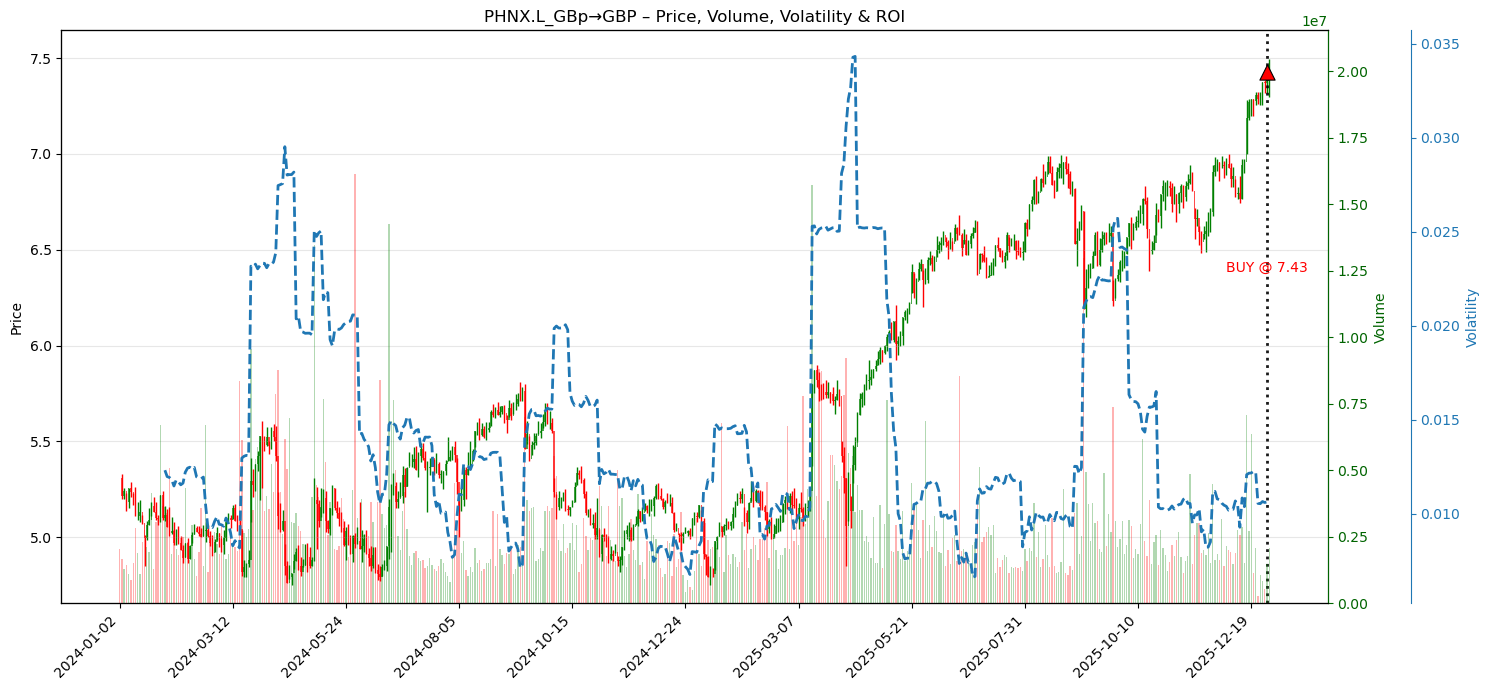

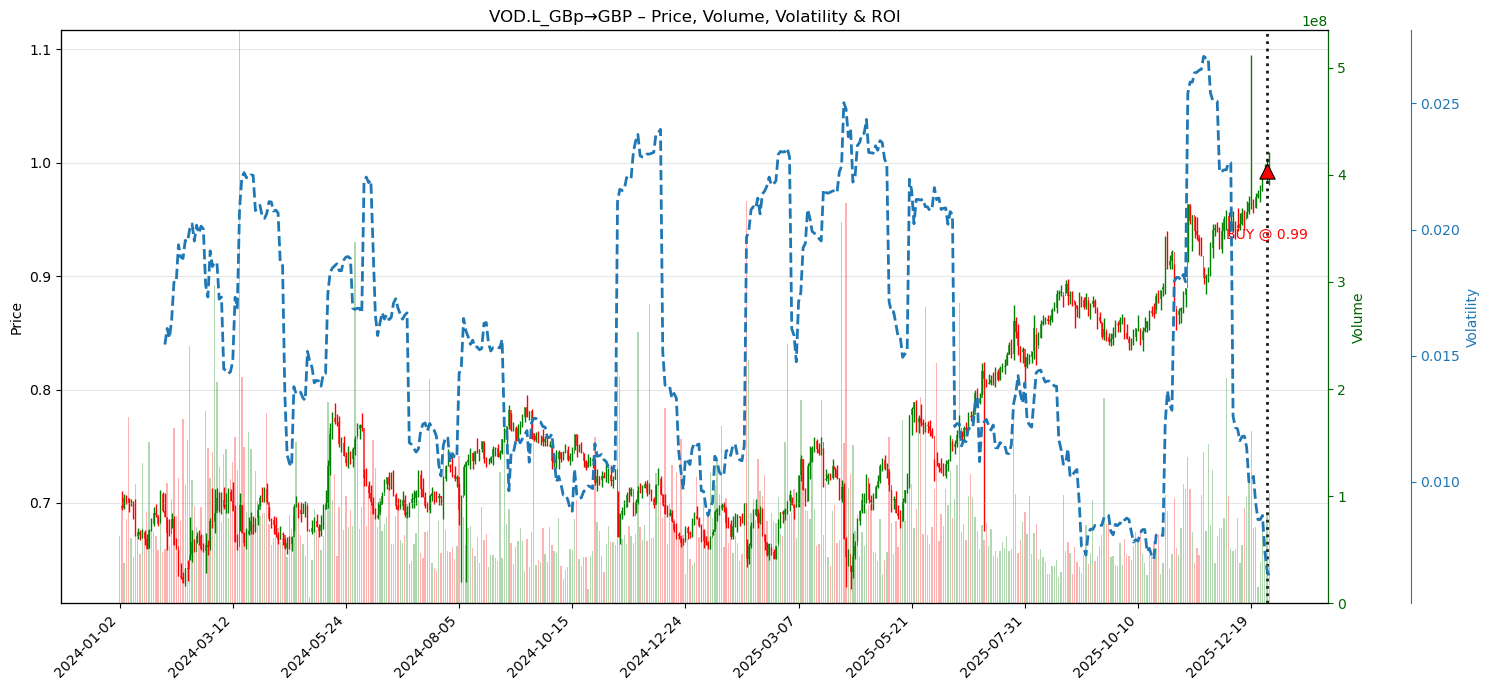

[DEBUG] File: c:\Users\ingca\OneDrive\Documents\python\finance\src\utils\retry_decorator.py, Function: wrapper, Line: 38
None plot_candles_volatility_volume_roi succeeded
ACTION     III.L_GBp→GBP                                                   \
CURRENCY             GBP                                                    
METRIC               LOW   HIGH  CLOSE    RANGE VOLATILITY   VOLUME   EPS   
Date                                                                        
2024-01-02      23.29998  24.22  23.44  0.92002        NaN  1518998  6.49   
2024-01-03      22.86000  23.50  23.14  0.64000        NaN  1851814  6.49   
2024-01-04      22.97000  23.37  23.37  0.40000        NaN  2246140  6.49   
2024-01-05      22.73000  23.17  22.93  0.44000        NaN  1606657  6.49   
2024-01-08      22.69000  23.19  23.19  0.50000        NaN  1368504  6.49   
...                  ...    ...    ...      ...        ...      ...   ...   
2025-12-29      32.17000  32.77  32.30  0.60000   0.018591 

In [11]:
shares_clean = [s.split('.')[0] for s in shares]
actions = df_shares_fund.columns.get_level_values('ACTION').unique()
mask = actions.str.contains('|'.join(shares), case=False, regex=True)
filtered_actions = actions[mask].to_list()
print(shares)
print(filtered_actions)
ROI(
    df=df_shares_fund,
    actions=filtered_actions,#shares,
    # actions=actions_list,
    start=df_shares_fund.index.min(),
    end=df_shares_fund.index.max(),
    purchase_date=purchase_date,
    roi_target=ROI_target
)
print(df_shares_fund)

# EMAIL SENDER

In [12]:
pics_dir = os.path.join(os.getcwd(),"output")
print(f"pics_dir: {pics_dir}")
print(f"portfolio:\n{portfolio}")
# print(f"df_fres: {df_fres}")
# print(f"type(df_fres): {type(df_fres)}")


# pp(portfolio, indent = 4)
# print(f"portfolio['ENT']['PURCHASE DATE']:{portfolio['ENT']['PURCHASE DATE']}")
# print(f"type(portfolio['ENT']['PURCHASE DATE']):{type(portfolio['ENT']['PURCHASE DATE'])}")


try:
    text_body, html_body, inline_images = build_roi_email_with_action_images(
        roi_data=portfolio, #df_fres,
        image_dir=pics_dir,  # contains AAL.png, VOD.png, ...
    )
except Exception as e:
    print(f"Could not run build_roi_email_with_action_images {type(e).__name__}: {e}")
print(f"text_body:\n{text_body}")
print(f"html_body:\n{html_body}")
try:
    send_email_html_multi_inline_images(
        smtp_server="smtp.gmail.com",
        smtp_port=587,
        username=email_sender,
        password=email_sender_psw,
        sender=email_sender,
        recipients=["ingcarldan@gmail.com"],
        subject=f"FTSE100 - ROI targets – {datetime.today():%d-%m-%Y %H:%M}",
        text_body=text_body,
        html_body=html_body,
        inline_images=inline_images,
    )
except Exception as e:
    print(f"Could not run send_email_html_multi_inline_images {type(e).__name__}: {e}")

pics_dir: c:\Users\ingca\OneDrive\Documents\python\finance\notebooks\output
portfolio:
{'FRES': {'ACTION': 'FRES.L_GBp→GBP', 'PURCHASE DATE': '02/01/2026', 'PURCHASE PRICE': 33.52, 'SET ROI TARGET': 0.135, 'DATE TARGET MET': None, 'EXIT ACTION PRICE': 34.96, 'DAYS TO ACHIEVE TARGET': None}, 'ENT': {'ACTION': 'ENT.L_GBp→GBP', 'PURCHASE DATE': '02/01/2026', 'PURCHASE PRICE': 7.71, 'SET ROI TARGET': 0.135, 'DATE TARGET MET': None, 'EXIT ACTION PRICE': 7.78, 'DAYS TO ACHIEVE TARGET': None}, 'GLEN': {'ACTION': 'GLEN.L_GBp→GBP', 'PURCHASE DATE': '02/01/2026', 'PURCHASE PRICE': 4.09, 'SET ROI TARGET': 0.135, 'DATE TARGET MET': None, 'EXIT ACTION PRICE': 4.19, 'DAYS TO ACHIEVE TARGET': None}, 'MNG': {'ACTION': 'MNG.L_GBp→GBP', 'PURCHASE DATE': '02/01/2026', 'PURCHASE PRICE': 2.91, 'SET ROI TARGET': 0.135, 'DATE TARGET MET': None, 'EXIT ACTION PRICE': 2.96, 'DAYS TO ACHIEVE TARGET': None}, 'PHNX': {'ACTION': 'PHNX.L_GBp→GBP', 'PURCHASE DATE': '02/01/2026', 'PURCHASE PRICE': 7.43, 'SET ROI TARGE

# PLOT PURCHASED SHARES

PURCHASED SHARES: ['FRES.L_GBp→GBP', 'ENT.L_GBp→GBP', 'GLEN.L_GBp→GBP', 'MNG.L_GBp→GBP', 'PHNX.L_GBp→GBP', 'VOD.L_GBp→GBP']
PURCHASED DATE: 2026-01-02 00:00:00


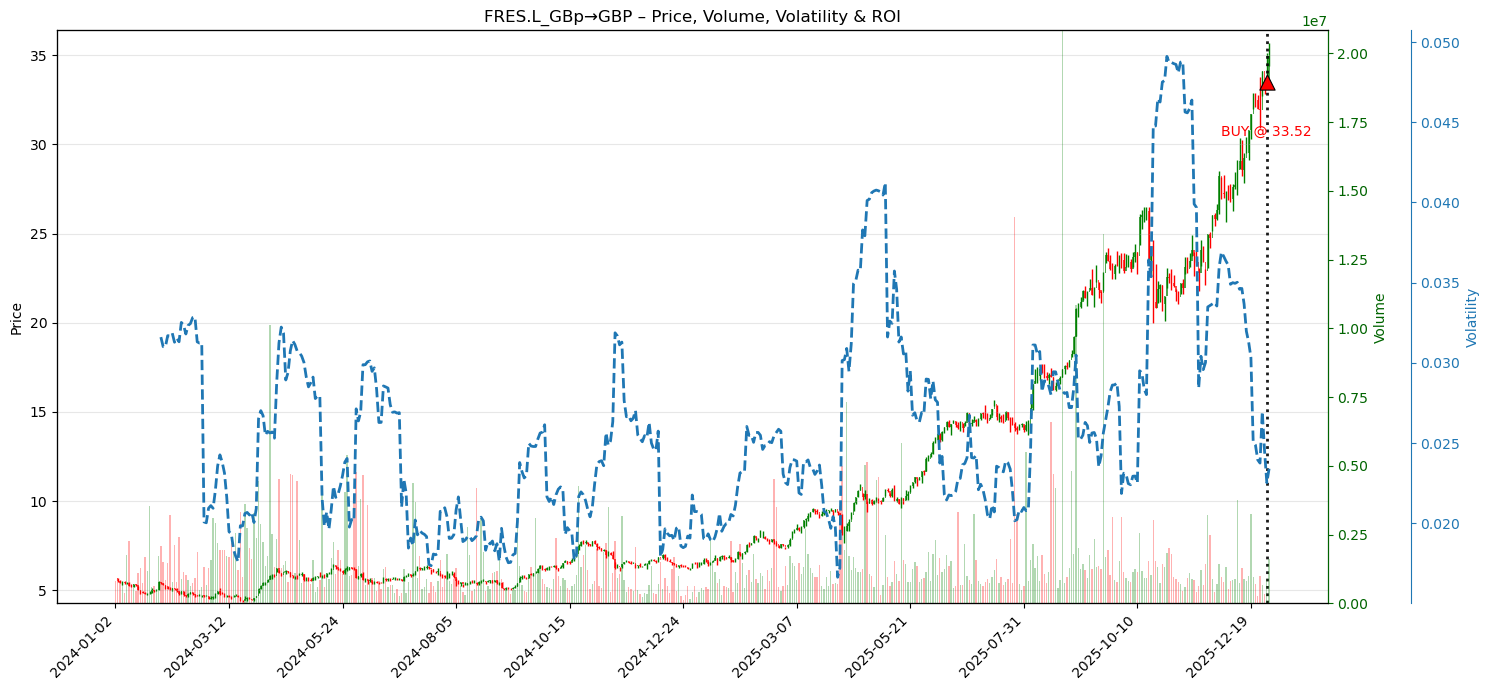

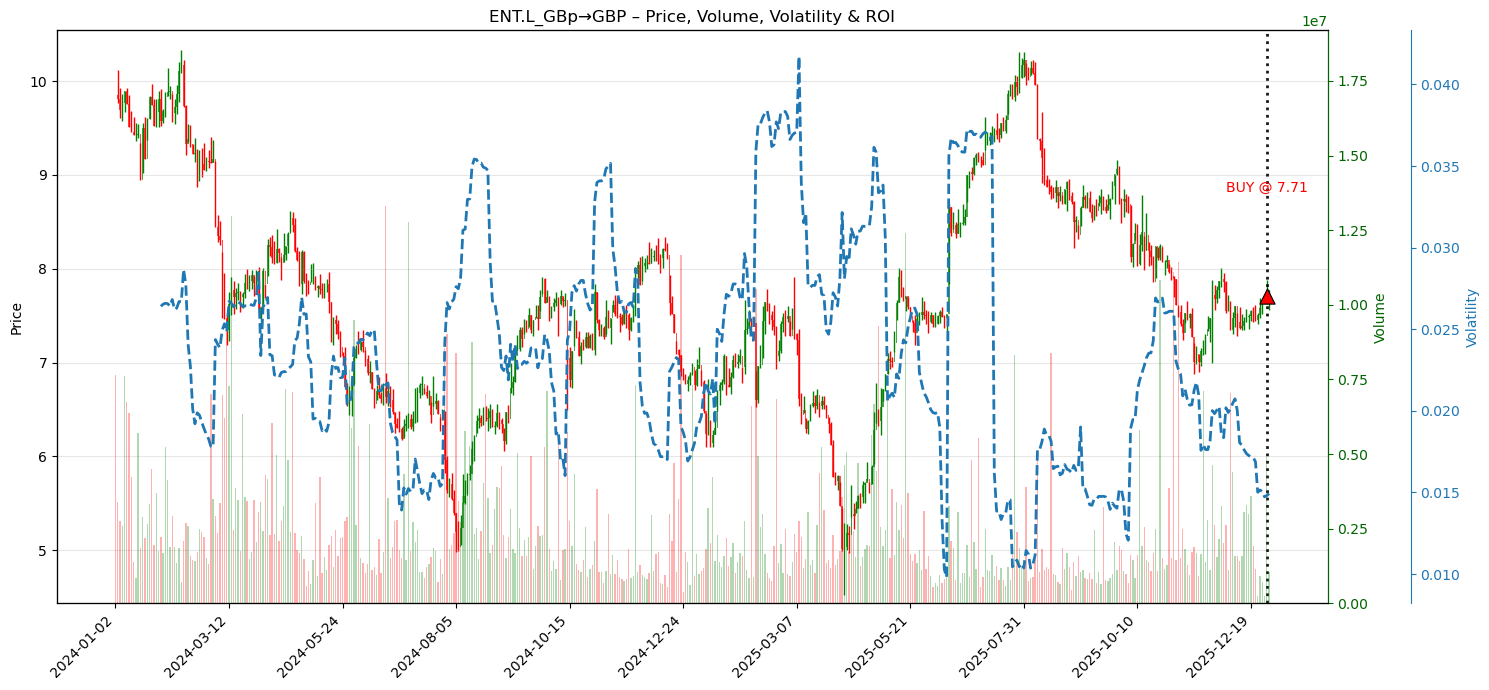

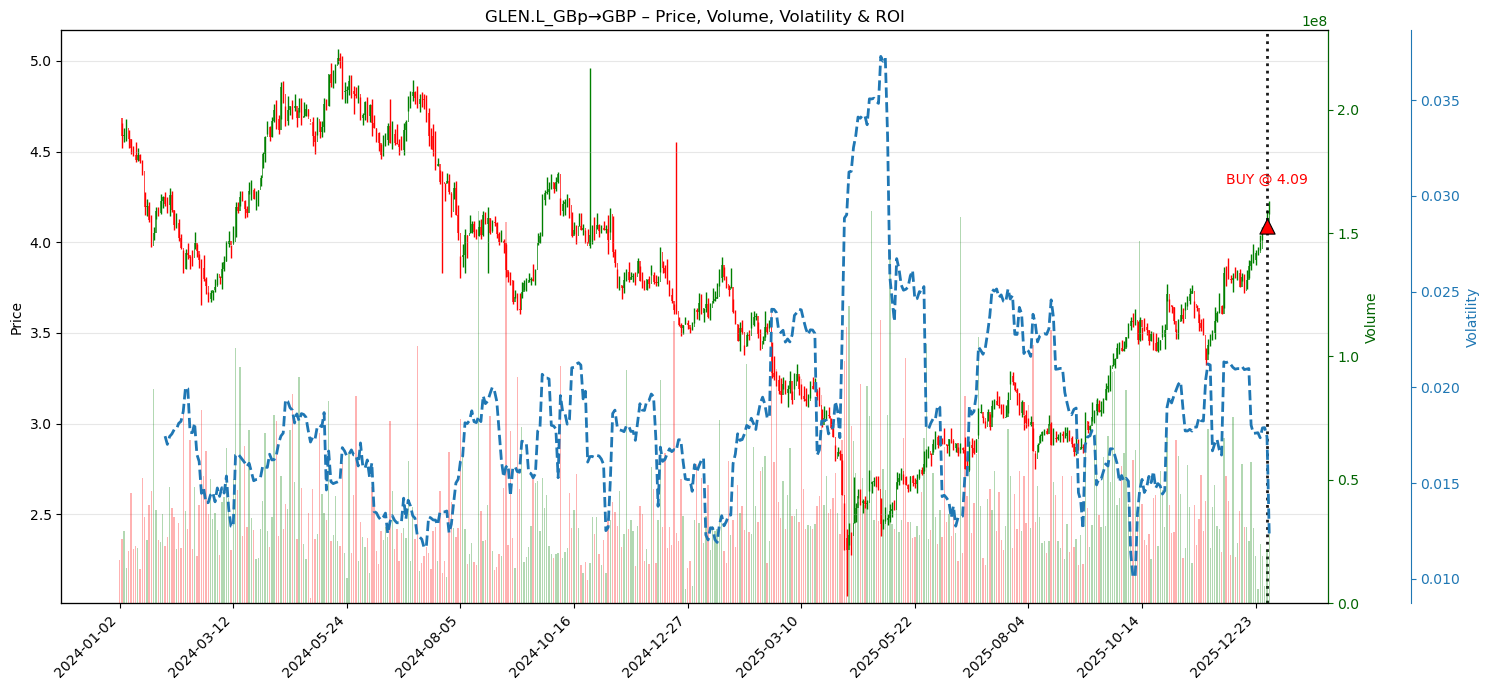

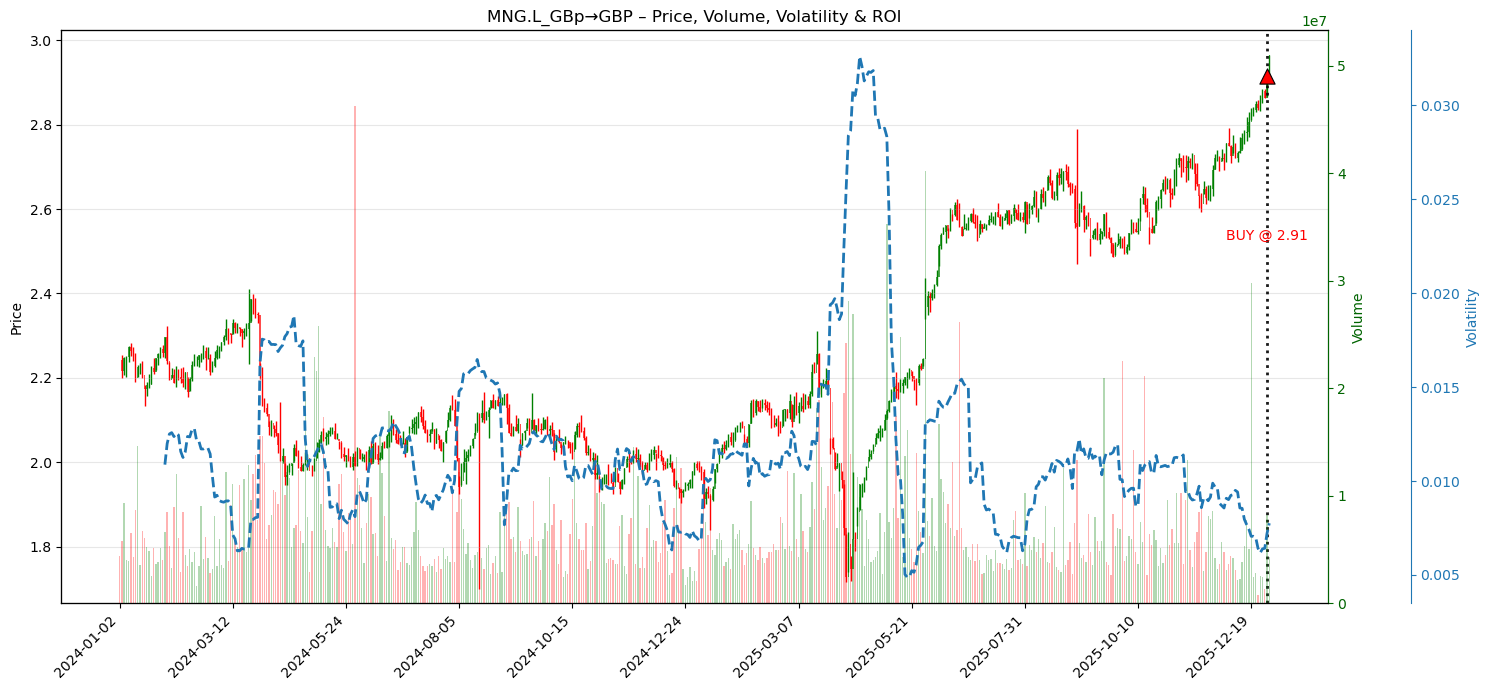

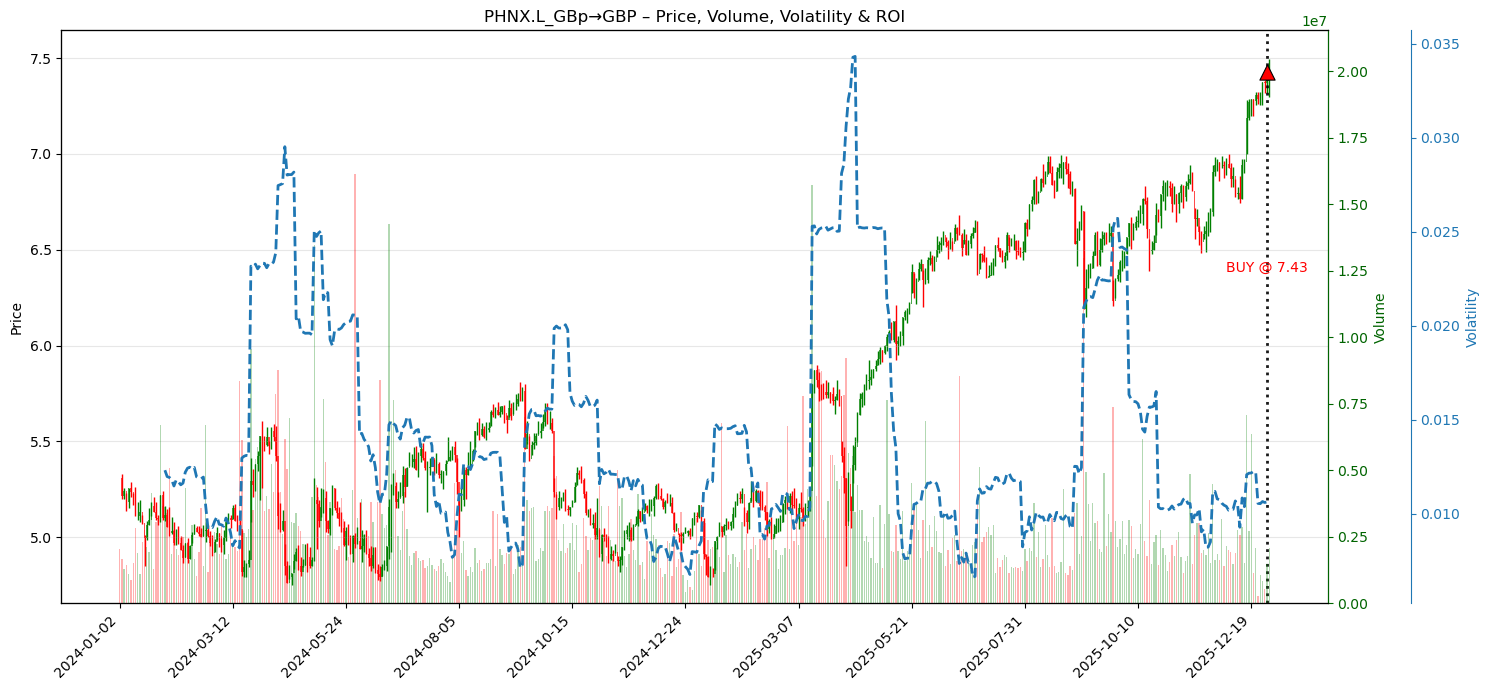

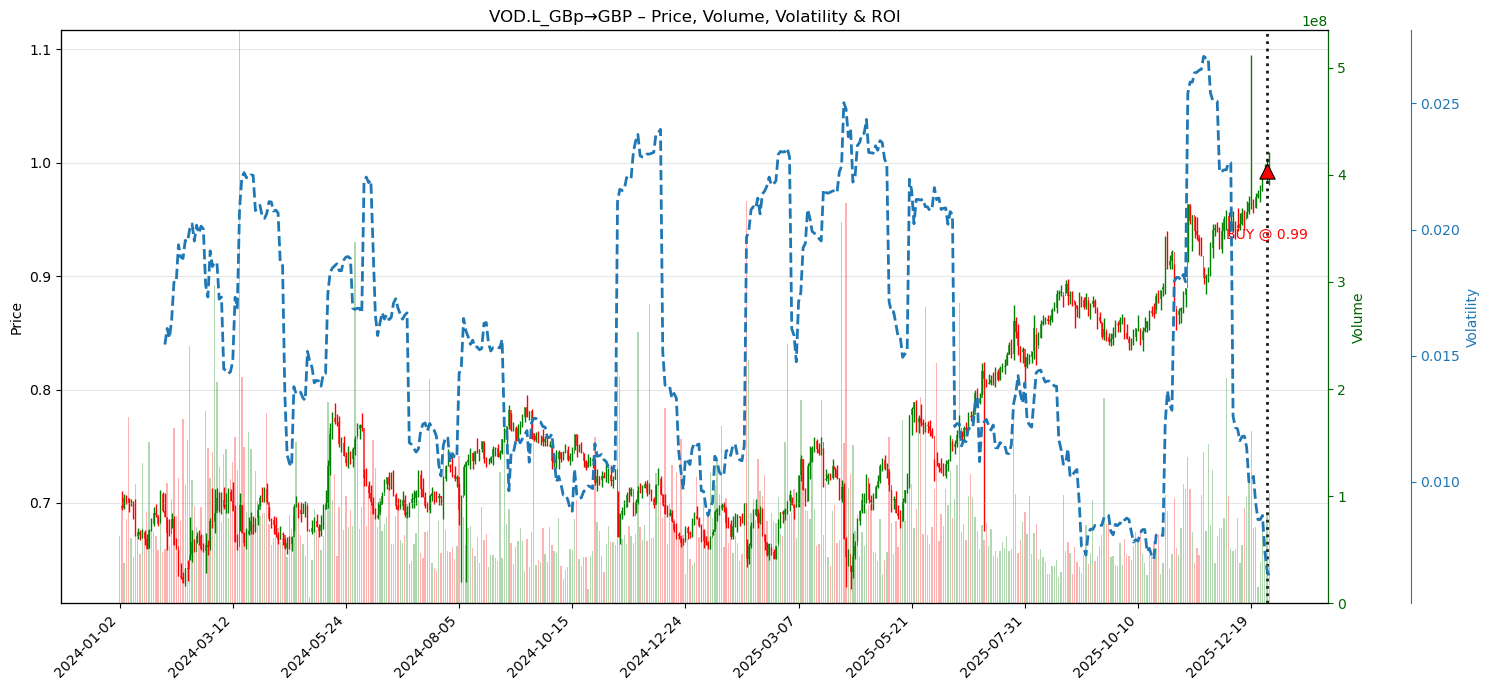

[DEBUG] File: c:\Users\ingca\OneDrive\Documents\python\finance\src\utils\retry_decorator.py, Function: wrapper, Line: 38
None plot_candles_volatility_volume_roi succeeded


In [13]:
# check if shares name ends with .L_GBP→GBP
for i, s in enumerate(shares):
    if not s.endswith('.L_GBp→GBP'):
        shares[i] = s + '.L_GBp→GBP'

print(f"PURCHASED SHARES: {shares}")
print(f"PURCHASED DATE: {purchase_date}")

ROI(
    df=df_shares_fund,
    actions=shares,
    start=df_shares_fund.index.min(),
    end=df_shares_fund.index.max(),
    purchase_date= purchase_date,
    roi_target=ROI_target
)